<a href="https://colab.research.google.com/github/arundhati-hive2/AlzheimersDetection/blob/main/alzheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Requirements

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
sns.set_palette("Blues")
plt.rcParams["figure.figsize"]=(10, 6)
print('All libraries have been loaded.')

All libraries have been loaded.


Checking the data

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("oasis_cross-sectional.csv")
print("\nShape of dataset:", df.shape)
print("\npreview:", df.head(10))

Saving oasis_cross-sectional.csv to oasis_cross-sectional.csv

Shape of dataset: (436, 12)

preview:               ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   
5  OAS1_0006_MR1   F    R   24   NaN  NaN   NaN  NaN  1131  0.862  1.551   
6  OAS1_0007_MR1   M    R   21   NaN  NaN   NaN  NaN  1516  0.830  1.157   
7  OAS1_0009_MR1   F    R   20   NaN  NaN   NaN  NaN  1505  0.843  1.166   
8  OAS1_0010_MR1   M    R   74   5.0  2.0  30.0  0.0  1636  0.689  1.073   
9  OAS1_0011_MR1   F    R   52   3.0  2.0  30.0  0.0  1321  0.827  1.329   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    Na

In [ ]:
print("Data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nMissing values %:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Data types:
ID        object
M/F       object
Hand      object
Age        int64
Educ     float64
SES      float64
MMSE     float64
CDR      float64
eTIV       int64
nWBV     float64
ASF      float64
Delay    float64
dtype: object

Missing values per column:
ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR      201
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64

Missing values %:
ID        0.00
M/F       0.00
Hand      0.00
Age       0.00
Educ     46.10
SES      50.46
MMSE     46.10
CDR      46.10
eTIV      0.00
nWBV      0.00
ASF       0.00
Delay    95.41
dtype: float64


In [ ]:
print("CDR Value Distribution")
print(df["CDR"].value_counts(dropna=False))
print("\nAge Distribution")
print(df["Age"].describe())
print("\nUnique values in M/F")
print(df["M/F"].unique())
print("Unique values in Hand")
print(df['Hand'].unique())

CDR Value Distribution
CDR
NaN    201
0.0    135
0.5     70
1.0     28
2.0      2
Name: count, dtype: int64

Age Distribution
count    436.000000
mean      51.357798
std       25.269862
min       18.000000
25%       23.000000
50%       54.000000
75%       74.000000
max       96.000000
Name: Age, dtype: float64

Unique values in M/F
['F' 'M']
Unique values in Hand
['R']


Classifying into non-demented and demented

In [ ]:
working_df = df.copy()
working_df['label'] = (working_df['CDR'] >= 0.5).astype(int)

print("Class Distribution")
print(working_df["label"].value_counts())

print(f'\nTotal samples: {len(working_df)}')

print("\nClasses: 0-> non-demented, 1->demented")

#dropping: ID, CDR, delay, hand

dropcols = ["ID", "CDR", "Delay", "Hand"]
working_df.drop(columns=dropcols, inplace=True)
print("Remaining columns:", working_df.columns.tolist())
print("Shape after dropping:", working_df.shape)

Class Distribution
label
0    336
1    100
Name: count, dtype: int64

Total samples: 436

Classes: 0-> non-demented, 1->demented
Remaining columns: ['M/F', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'label']
Shape after dropping: (436, 9)


Filtering

In [ ]:
print("Missing Values Before Filling")
print(working_df.isnull().sum())

# Filling with median
for col in ["SES", "MMSE", "Educ"]:
    if working_df[col].isnull().sum() > 0:
        median_val = working_df[col].median()
        working_df[col] = working_df[col].fillna(median_val)
        print(f"Filled {col} missing values with median: {median_val}")

print("Missing Values After Filling")
print(working_df.isnull().sum())

Missing Values Before Filling
M/F        0
Age        0
Educ     201
SES      220
MMSE     201
eTIV       0
nWBV       0
ASF        0
label      0
dtype: int64
Filled SES missing values with median: 2.0
Filled MMSE missing values with median: 29.0
Filled Educ missing values with median: 3.0
Missing Values After Filling
M/F      0
Age      0
Educ     0
SES      0
MMSE     0
eTIV     0
nWBV     0
ASF      0
label    0
dtype: int64


In [ ]:
working_df["M/F"] = working_df["M/F"].map({'M': 0, 'F': 1})

print("Data Types After Encoding")
print(working_df.dtypes)

print("Sample of Cleaned Data")
working_df.head()

Data Types After Encoding
M/F        int64
Age        int64
Educ     float64
SES      float64
MMSE     float64
eTIV       int64
nWBV     float64
ASF      float64
label      int64
dtype: object
Sample of Cleaned Data


,M/F,Age,Educ,SES,MMSE,eTIV,nWBV,ASF,label
0,1,74,2.0,3.0,29.0,1344,0.743,1.306,0
1,1,55,4.0,1.0,29.0,1147,0.810,1.531,0
2,1,73,4.0,3.0,27.0,1454,0.708,1.207,1
3,0,28,3.0,2.0,29.0,1588,0.803,1.105,0
4,0,18,3.0,2.0,29.0,1737,0.848,1.010,0


no majoritarianism?

Class Distribution Before Balancing:
class count:  label
0    336
1    100
Name: count, dtype: int64 
class percentages: label
0    77.06
1    22.94
Name: proportion, dtype: float64


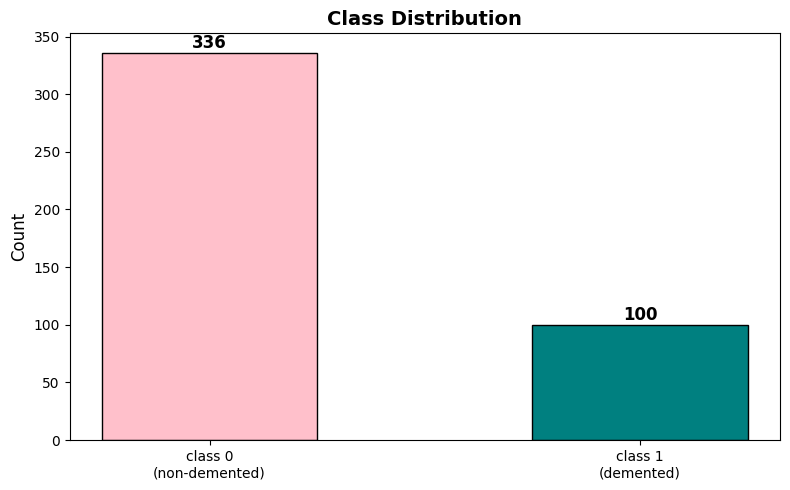

In [ ]:
class_counts = working_df["label"].value_counts()
print("Class Distribution Before Balancing:")
class_pct = working_df["label"].value_counts(normalize=True) * 100
print("class count: ", class_counts, "\nclass percentages:", class_pct.round(2))

#plotting
fig, ax = plt.subplots(figsize = (8,5))
bars = ax.bar(['class 0\n(non-demented)', 'class 1\n(demented)'], class_counts.values, color = ['pink', 'teal'], edgecolor='black', width=0.5)

for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

AGE DISTRIBUTION BY CLASS

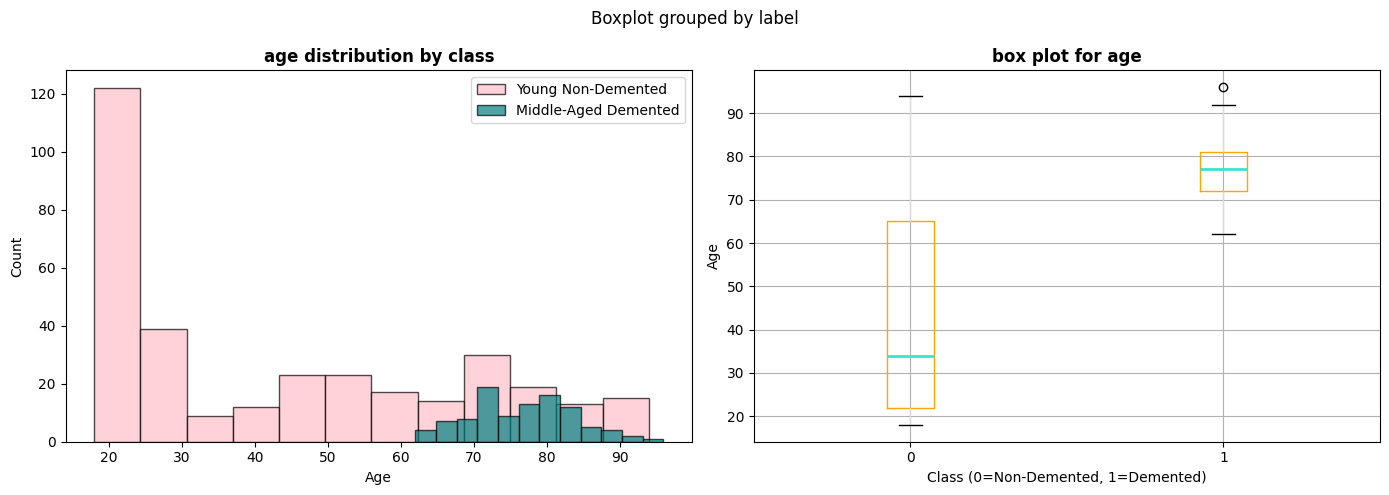

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color, name in zip([0, 1], ['pink', 'teal'], ['Young Non-Demented', 'Middle-Aged Demented']):
    subset = working_df [ working_df['label']==label ] ["Age"]
    axes[0].hist(subset, bins=12, alpha=0.7, color=color, label=name, edgecolor='black')

axes[0].set_title("age distribution by class", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot of Age
working_df.boxplot(column="Age", by="label", ax=axes[1],
                   boxprops=dict(color="orange"),
                   medianprops=dict(color="turquoise", linewidth=2))
axes[1].set_title("box plot for age", fontweight="bold")
axes[1].set_xlabel("Class (0=Non-Demented, 1=Demented)")
axes[1].set_ylabel("Age")
plt.tight_layout()
plt.show()

MOST RELEVANT FEATURES

/tmp/ipykernel_4926/4093578540.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data0, data1], labels=["Class 0\n(Non-Demented)", "Class 1\n(Demented)"], patch_artist=True, medianprops=dict(color="black", linewidth=2))
/tmp/ipykernel_4926/4093578540.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data0, data1], labels=["Class 0\n(Non-Demented)", "Class 1\n(Demented)"], patch_artist=True, medianprops=dict(color="black", linewidth=2))


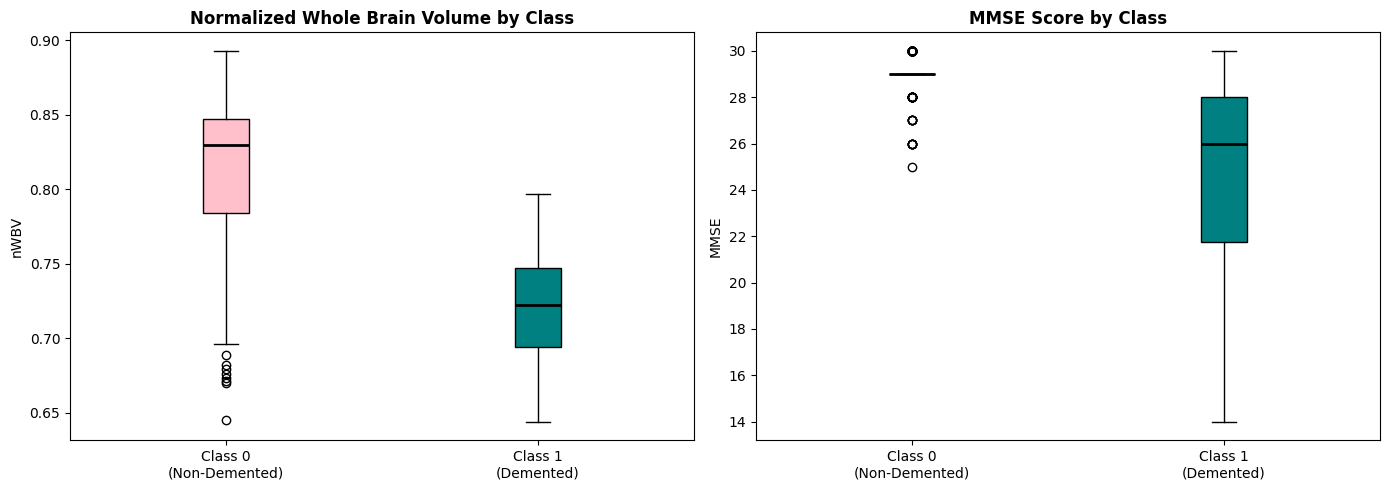

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,["nWBV", "MMSE"], ["Normalized Whole Brain Volume by Class", "MMSE Score by Class"]):
    data0 = working_df[working_df["label"] == 0][col]
    data1 = working_df[working_df["label"] == 1][col]
    #plotting
    bp = ax.boxplot([data0, data1], labels=["Class 0\n(Non-Demented)", "Class 1\n(Demented)"], patch_artist=True, medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("pink")
    bp["boxes"][1].set_facecolor("teal")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

BOX PLOTS for weaker predictors

/tmp/ipykernel_4926/662090731.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data0, data1], labels=["Class 0", "Class 1"], patch_artist=True)
/tmp/ipykernel_4926/662090731.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data0, data1], labels=["Class 0", "Class 1"], patch_artist=True)
/tmp/ipykernel_4926/662090731.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data0, data1], labels=["Class 0", "Class 1"], patch_artist=True)


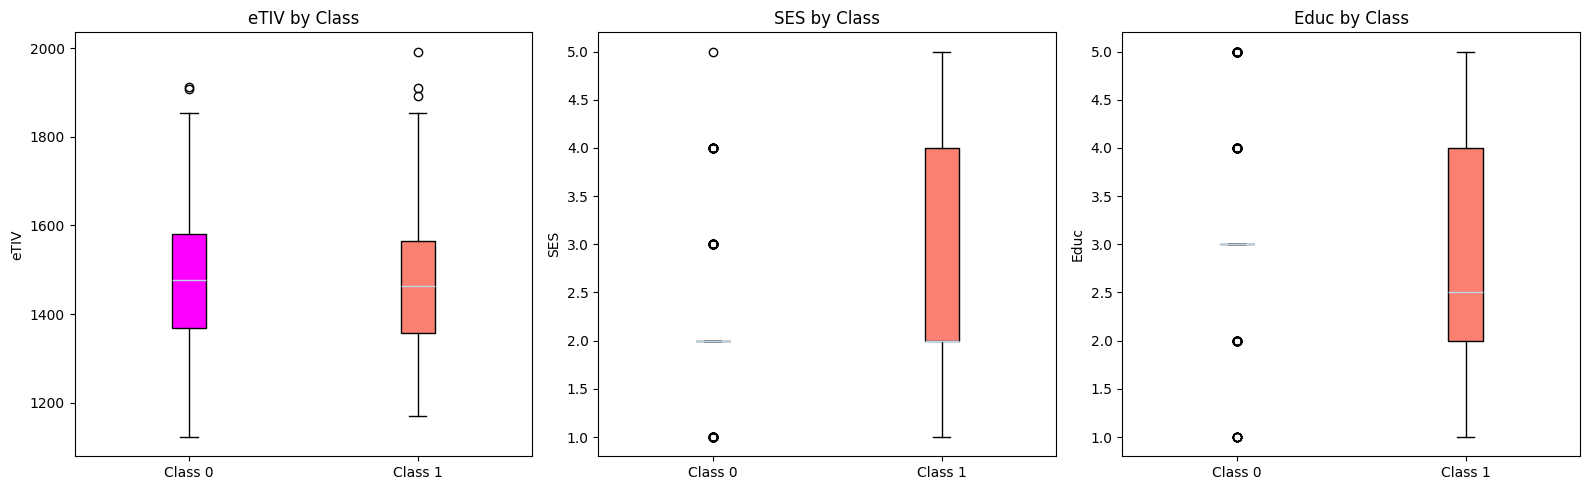

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["eTIV", "SES", "Educ"]):
    data0 = working_df[working_df["label"] == 0][col]
    data1 = working_df[working_df["label"] == 1][col]
    #plotting
    bp = ax.boxplot([data0, data1], labels=["Class 0", "Class 1"], patch_artist=True)
    bp["boxes"][0].set_facecolor("magenta")
    bp["boxes"][1].set_facecolor("salmon")
    ax.set_title(f"{col} by Class")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

GENDER

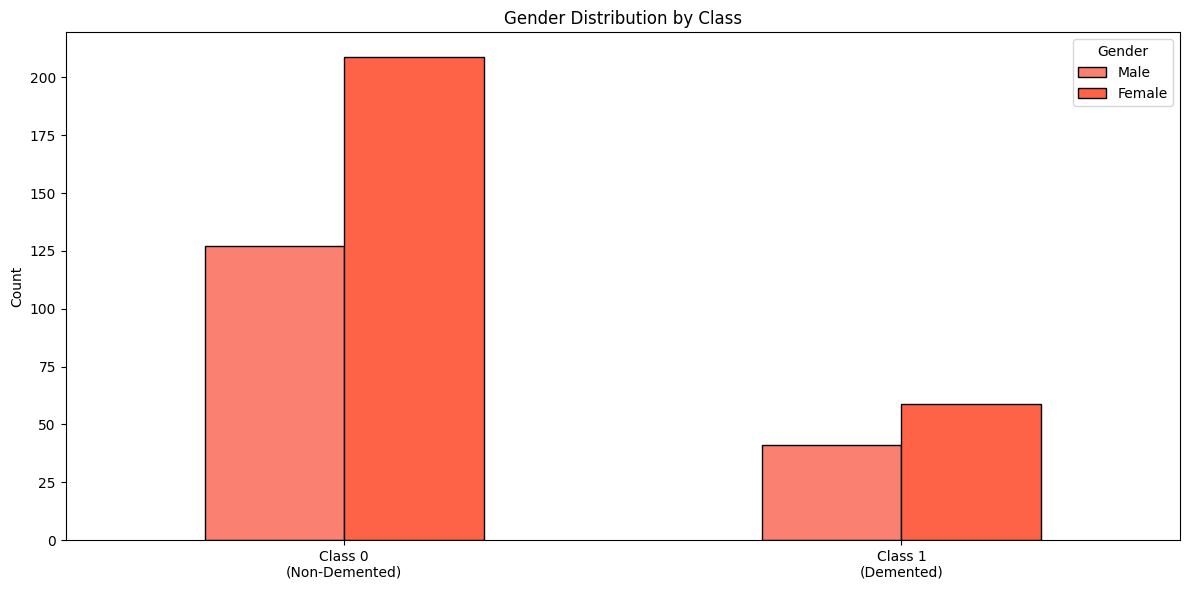

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))
gender_class = working_df.groupby(["label", "M/F"]).size().unstack()
gender_class.columns = ["Male", "Female"]
gender_class.index = ["Class 0\n(Non-Demented)", "Class 1\n(Demented)"]
gender_class.plot(kind="bar", ax=ax, color=["SALMON", "TOMATO"], edgecolor="black", rot=0)
ax.set_title("Gender Distribution by Class")
ax.set_ylabel("Count")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

CORRELATION

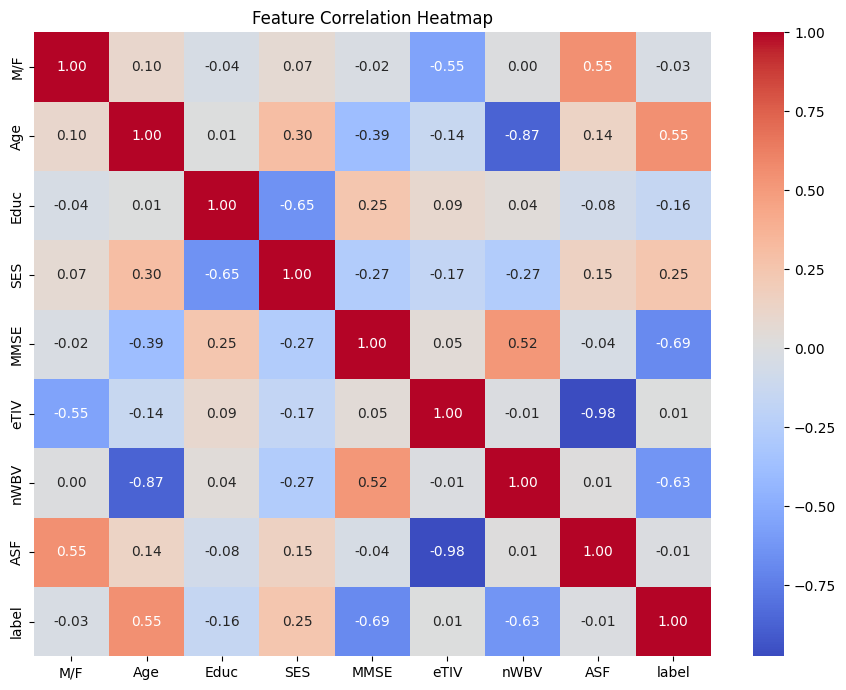

In [ ]:

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = working_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

PAIRPLOT

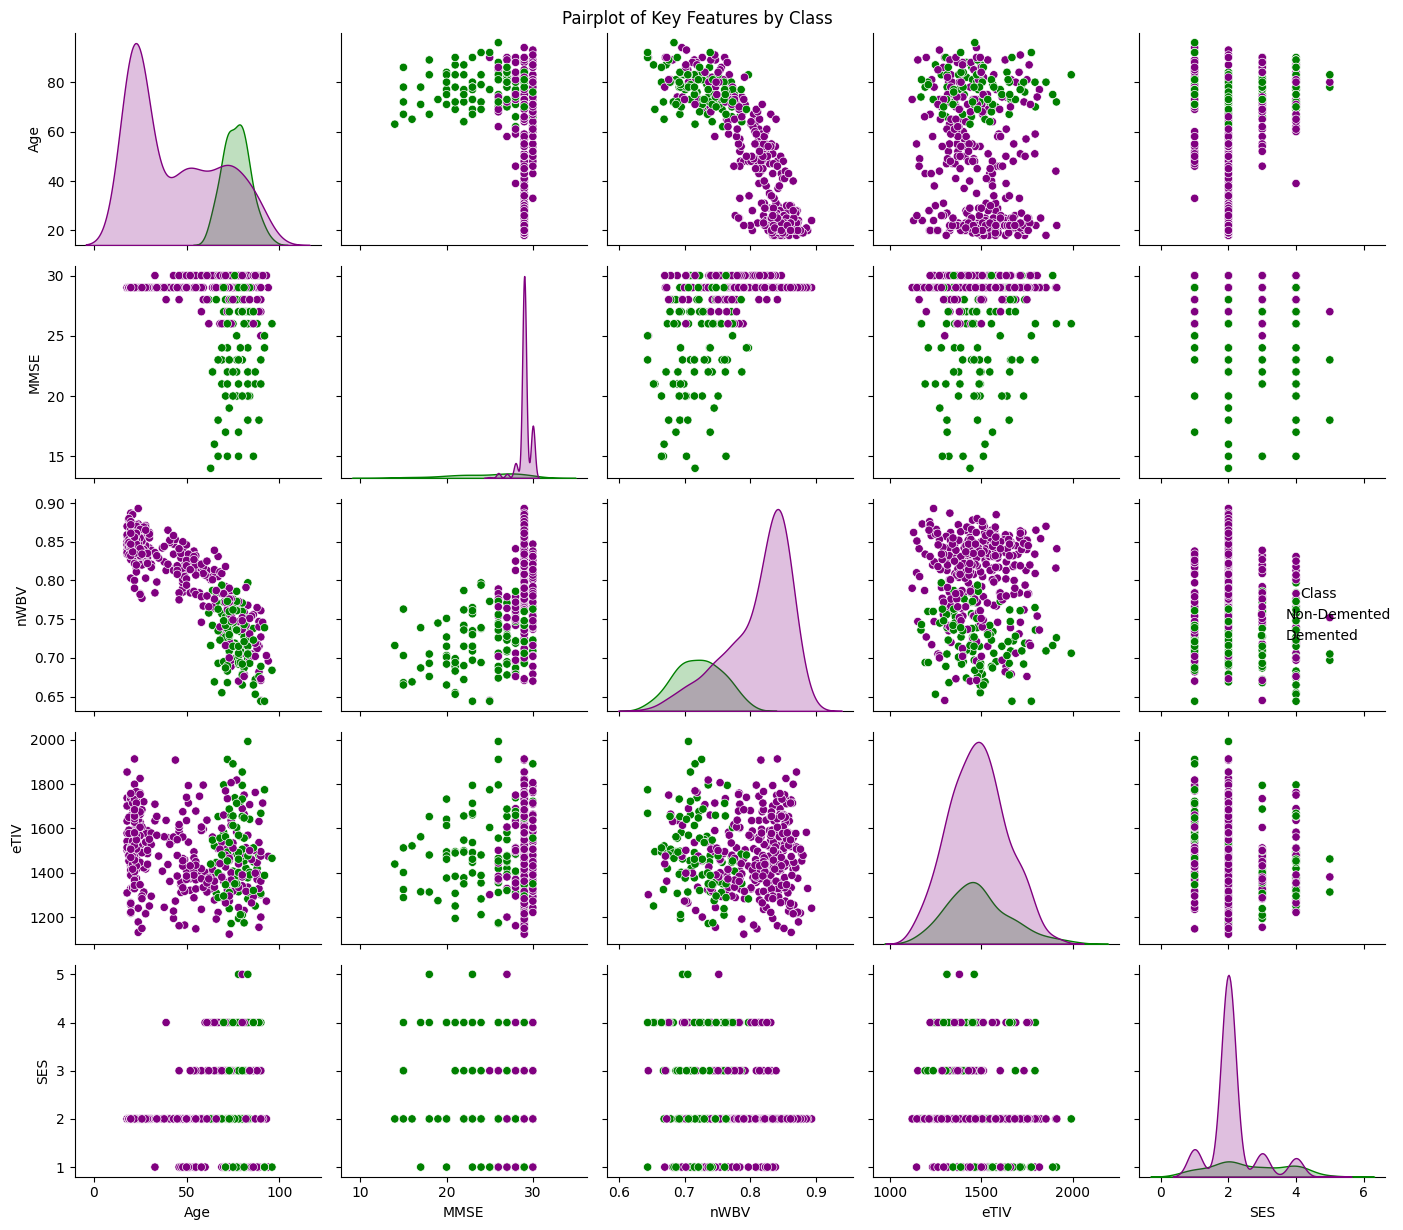

In [ ]:
features_for_pair = ["Age", "MMSE", "nWBV", "eTIV", "SES", "label"]
pair_df = working_df[features_for_pair].copy()
pair_df["Class"] = pair_df["label"].map({0: "Non-Demented", 1: "Demented"})
g = sns.pairplot(pair_df.drop("label", axis=1), hue="Class", palette={"Non-Demented": "purple", "Demented": "green"})
g.fig.suptitle("Pairplot of Key Features by Class")
plt.tight_layout()
plt.show()

nwbv is most significant
followed by mmse and age
etiv and asf are inversely related
ses and educ are not very significant

training and testing

In [ ]:
X = working_df.drop("label", axis=1)
y = working_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining class distribution count\n{y_train.value_counts()}")
print(f"\nTest class distribution count\n{y_test.value_counts()}")

Training set size: 348 samples
Test set size: 88 samples

Training class distribution count
label
0    268
1     80
Name: count, dtype: int64

Test class distribution count
label
0    68
1    20
Name: count, dtype: int64


using smote

In [ ]:
print("before smote count\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nafter smote count")
print(pd.Series(y_train_sm).value_counts())
print(f"\ntraining set size after SMOTE: {X_train_sm.shape[0]} samples")

before smote count
 label
0    268
1     80
Name: count, dtype: int64

after smote count
label
0    268
1    268
Name: count, dtype: int64

training set size after SMOTE: 536 samples


standardize the values of the features

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("scaling over")
print(f"training set shape - {X_train_sc.shape}")
print(f"test set shape - {X_test_sc.shape}")

scaling over
training set shape - (536, 8)
test set shape - (88, 8)


evaluation


=== Logistic Regression (Baseline) ===
Accuracy, 0.8295
Precision, 0.5926
Recall, 0.8000
F1 Score, 0.6809
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.93      0.84      0.88        68
    Demented       0.59      0.80      0.68        20

    accuracy                           0.83        88
   macro avg       0.76      0.82      0.78        88
weighted avg       0.86      0.83      0.84        88



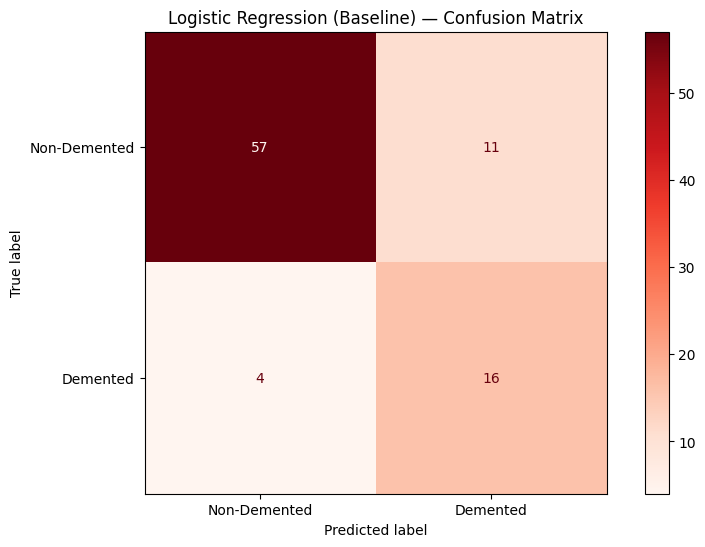

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name="Model"):
    model.fit(X_tr, y_tr)
    y_pred=model.predict(X_te)
    acc=accuracy_score(y_te, y_pred)
    prec=precision_score(y_te, y_pred, zero_division=0)
    rec=recall_score(y_te, y_pred, zero_division=0)
    f1=f1_score(y_te, y_pred, zero_division=0)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy, {acc:.4f}")
    print(f"Precision, {prec:.4f}")
    print(f"Recall, {rec:.4f}")
    print(f"F1 Score, {f1:.4f}")
    print("Classification Report:", classification_report(y_te, y_pred, target_names=["Non-Demented", "Demented"]))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Demented", "Demented"])
    disp.plot(cmap='Reds')
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()
    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

r=[]
lr_baseline = LogisticRegression(random_state=42)
r2= evaluate_model(lr_baseline, X_train_sc, y_train_sm, X_test_sc, y_test, model_name="Logistic Regression (Baseline)")
r.append(r2)

feature selection

/tmp/ipykernel_4926/1103089243.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


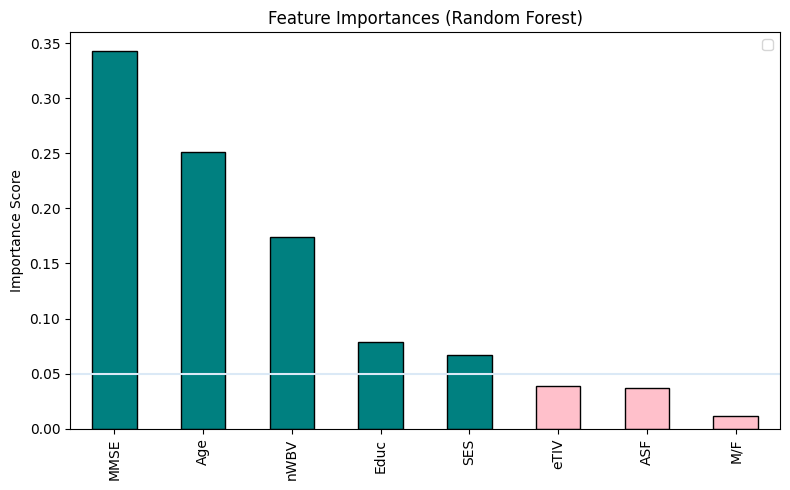


Importance Scores:
MMSE    0.3426
Age     0.2513
nWBV    0.1743
Educ    0.0787
SES     0.0665
eTIV    0.0384
ASF     0.0370
M/F     0.0113
dtype: float64


In [ ]:
# Train Random Forest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_sc, y_train_sm)
importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

# plot feature importances
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="bar", ax=ax,
                 color=["pink" if i < 0.05 else "teal" for i in importances],
                 edgecolor="black")
ax.axhline(y=0.05)
ax.set_title("Feature Importances (Random Forest)")
ax.set_ylabel("Importance Score")
ax.legend()
plt.tight_layout()
plt.show()

print("\nImportance Scores:")
print(importances.round(4))

Select features above the mean importance threshold

Threshold, 0.1250
Selected features, ['MMSE', 'Age', 'nWBV']
Dropped features, ['Educ', 'SES', 'eTIV', 'ASF', 'M/F']

=== Reduced Logistic Regression ===
Accuracy, 0.8068
Precision, 0.5517
Recall, 0.8000
F1 Score, 0.6531
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.93      0.81      0.87        68
    Demented       0.55      0.80      0.65        20

    accuracy                           0.81        88
   macro avg       0.74      0.80      0.76        88
weighted avg       0.85      0.81      0.82        88



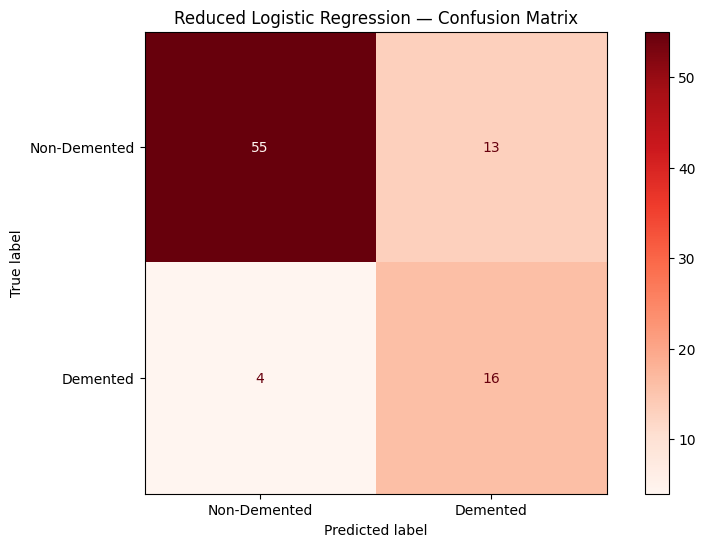

In [ ]:

threshold=importances.mean()
selected_features=importances[importances >= threshold].index.tolist()
dropped_features=importances[importances < threshold].index.tolist()
print(f"Threshold, {threshold:.4f}")
print(f"Selected features, {selected_features}")
print(f"Dropped features, {dropped_features}")

feature_cols=list(X.columns)
selected_idx=[feature_cols.index(f) for f in selected_features]
X_train_fs=X_train_sc[:, selected_idx]
X_test_fs=X_test_sc[:, selected_idx]

# Retrain on reduced feature set
lr_fs = LogisticRegression(random_state=42)
res_fs = evaluate_model(lr_fs, X_train_fs, y_train_sm, X_test_fs, y_test, model_name="Reduced Logistic Regression")
r.append(res_fs)


=== Random Forest (Default) ===
Accuracy, 0.8750
Precision, 0.6667
Recall, 0.9000
F1 Score, 0.7660
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.97      0.87      0.91        68
    Demented       0.67      0.90      0.77        20

    accuracy                           0.88        88
   macro avg       0.82      0.88      0.84        88
weighted avg       0.90      0.88      0.88        88



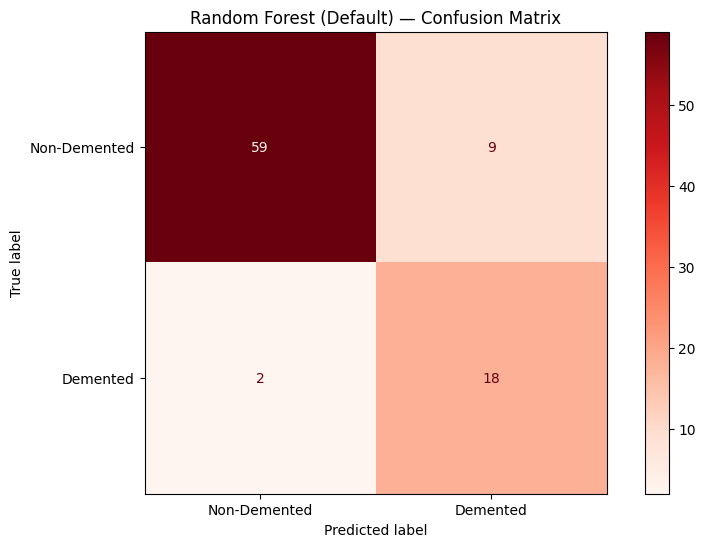

In [ ]:
rf_default = RandomForestClassifier(n_estimators=100, random_state=42)
res_rf = evaluate_model(rf_default, X_train_sc, y_train_sm, X_test_sc, y_test, model_name="Random Forest (Default)")
r.append(res_rf) #for Default

Max Margin


=== svm (Default) ===
Accuracy, 0.7841
Precision, 0.5152
Recall, 0.8500
F1 Score, 0.6415
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.95      0.76      0.85        68
    Demented       0.52      0.85      0.64        20

    accuracy                           0.78        88
   macro avg       0.73      0.81      0.74        88
weighted avg       0.85      0.78      0.80        88



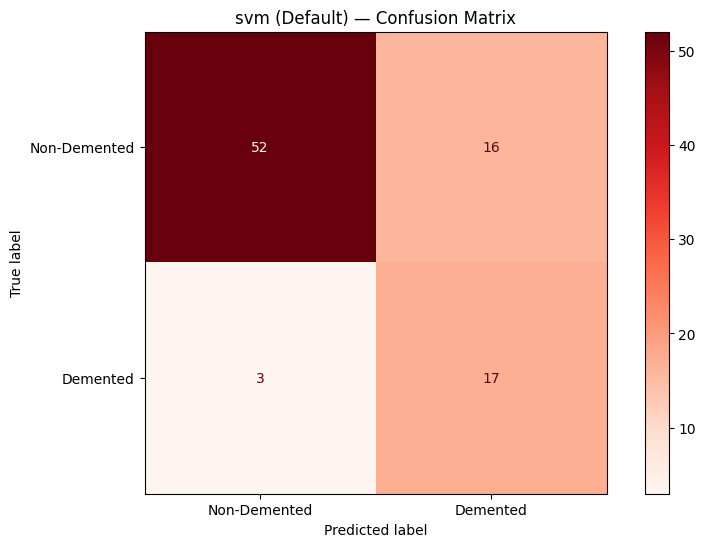

In [ ]:
svm_default = SVC(random_state=42, probability=True)
res_svm = evaluate_model(svm_default, X_train_sc, y_train_sm,X_test_sc, y_test, model_name="svm (Default)")
r.append(res_svm)

gridsearchcv - hyperparameter tune


In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

rf_tune = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_tune, param_grid_rf, cv=5, scoring="f1", n_jobs=-1, verbose=1)
grid_search.fit(X_train_sc, y_train_sm)

print("BEST PARAMETERS:", grid_search.best_params_)
print(f"\nBest Cross-Validated F1 Score, {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
BEST PARAMETERS: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validated F1 Score, 0.9385


Evaluating on test set


=== Random Forest Tuned ===
Accuracy, 0.8523
Precision, 0.6207
Recall, 0.9000
F1 Score, 0.7347
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.97      0.84      0.90        68
    Demented       0.62      0.90      0.73        20

    accuracy                           0.85        88
   macro avg       0.79      0.87      0.82        88
weighted avg       0.89      0.85      0.86        88



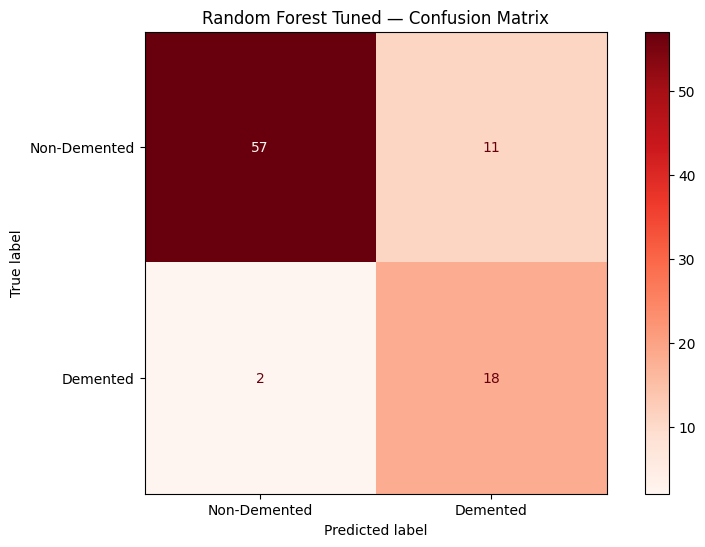

In [ ]:
best_rf = grid_search.best_estimator_
res_tuned = evaluate_model(best_rf, X_train_sc, y_train_sm, X_test_sc, y_test, model_name="Random Forest Tuned")
r.append(res_tuned)

         C  Train F1  Test F1
0    0.001    0.9088   0.6538
1    0.010    0.9250   0.6667
2    0.100    0.9287   0.6531
3    1.000    0.9294   0.6809
4   10.000    0.9291   0.6957
5  100.000    0.9271   0.6667


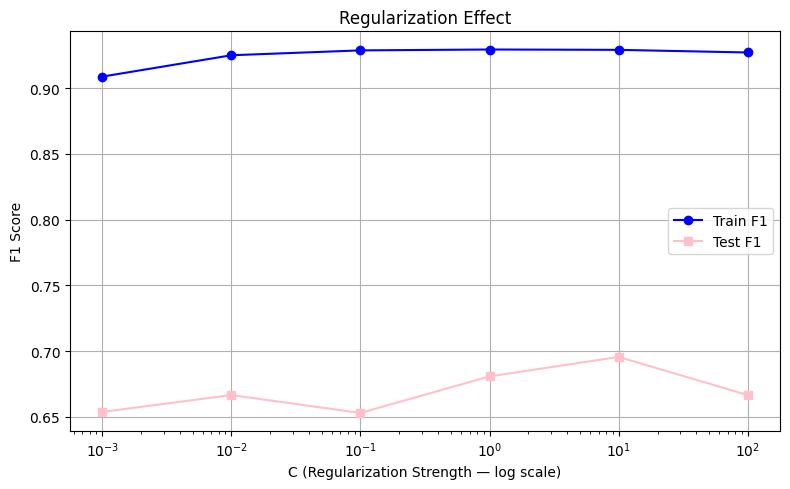

Best C value based on Test F1, 10.0

=== Logistic Regression (L2, C=10.0) ===
Accuracy, 0.8409
Precision, 0.6154
Recall, 0.8000
F1 Score, 0.6957
Classification Report:               precision    recall  f1-score   support

Non-Demented       0.94      0.85      0.89        68
    Demented       0.62      0.80      0.70        20

    accuracy                           0.84        88
   macro avg       0.78      0.83      0.79        88
weighted avg       0.86      0.84      0.85        88



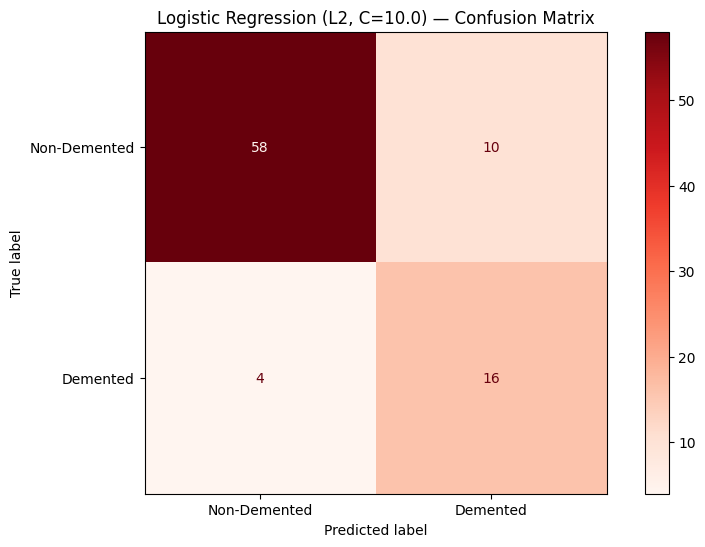

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
reg_results = []

for c in C_values:
    lr_reg=LogisticRegression(C=c, penalty="l2", random_state=42, max_iter=1000)

    lr_reg.fit(X_train_sc, y_train_sm)

    train_f1=f1_score(y_train_sm, lr_reg.predict(X_train_sc))
    test_f1=f1_score(y_test, lr_reg.predict(X_test_sc))

    reg_results.append({
        "C": c,
        "Train F1": train_f1,
        "Test F1": test_f1 })

reg_df = pd.DataFrame(reg_results)
print(reg_df.round(4))

# Plot train vs test F1 across C values
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(reg_df["C"], reg_df["Train F1"], "o-",
            label="Train F1", color="blue")

ax.semilogx(reg_df["C"], reg_df["Test F1"], "s-",
            label="Test F1", color="pink")

ax.set_xlabel("C (Regularization Strength — log scale)")
ax.set_ylabel("F1 Score")
ax.set_title("Regularization Effect")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Best C from regularization analysis
best_c = reg_df.loc[reg_df["Test F1"].idxmax(), "C"]
print(f"Best C value based on Test F1, {best_c}")

lr_regularized = LogisticRegression(
    C=best_c,
    penalty="l2",
    random_state=42,
    max_iter=1000)

res_reg = evaluate_model(
    lr_regularized,
    X_train_sc,
    y_train_sm,
    X_test_sc,
    y_test,
    model_name=f"Logistic Regression (L2, C={best_c})")

r.append(res_reg)

Final comparison

Final Model Comparison


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression (Baseline),0.8295,0.5926,0.80,0.6809
Reduced Logistic Regression,0.8068,0.5517,0.80,0.6531
Random Forest (Default),0.8750,0.6667,0.90,0.7660
svm (Default),0.7841,0.5152,0.85,0.6415
Random Forest Tuned,0.8523,0.6207,0.90,0.7347
"Logistic Regression (L2, C=10.0)",0.8409,0.6154,0.80,0.6957


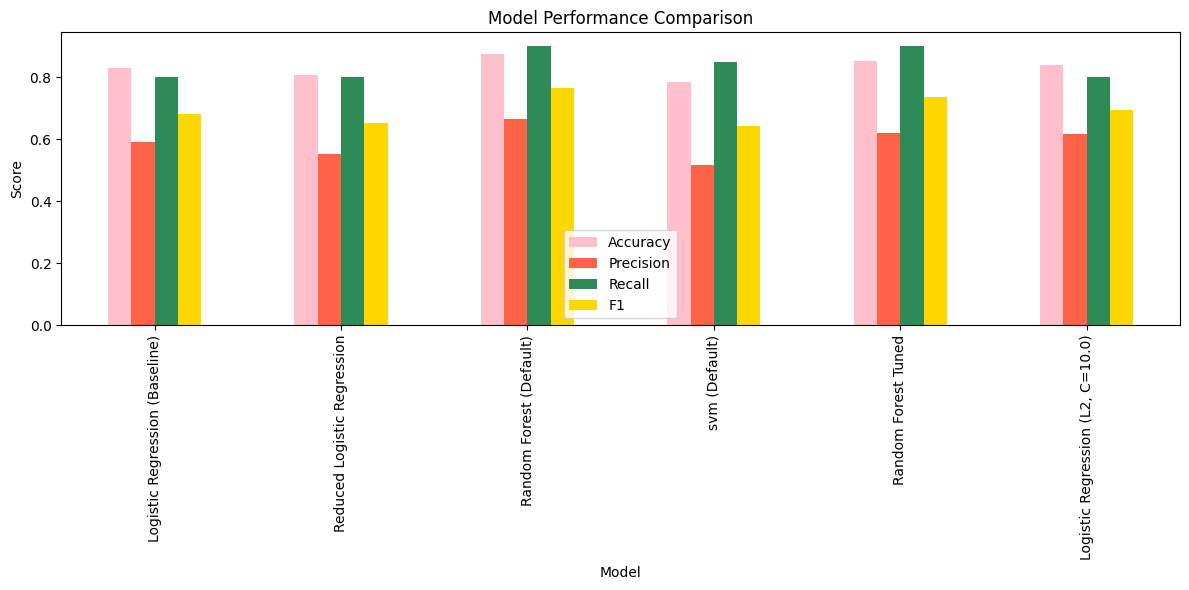

In [ ]:
results_df = pd.DataFrame(r)
results_df = results_df.set_index("Model")
results_df = results_df.round(4)
print("Final Model Comparison")
display(results_df)

# Visual
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind="bar", ax=ax, color=["pink", "tomato", "seagreen", "gold"])
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()